# 1 - What is a network?

Today: **node, edge, neighbour, degree, path**. You only need variables, lists and `for` loops. Run the examples, then complete the short **Your turn** cells.

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

### 1 - A simple network from scratch

A **node** is a person. An **edge** (or link) connects two people who can transmit infection to one another. A contact is an opportunity for transmission, not a guaranteed infection.

We use an **undirected** network: an edge works in both directions. It is **unweighted**: all edges have the same transmission rule. It is **static**: contacts stay fixed during a simulation.

A pair such as `(0, 1)` is a Python tuple. A list of these pairs is an **edge list**. The numbers are names for people, not their ages or health states.

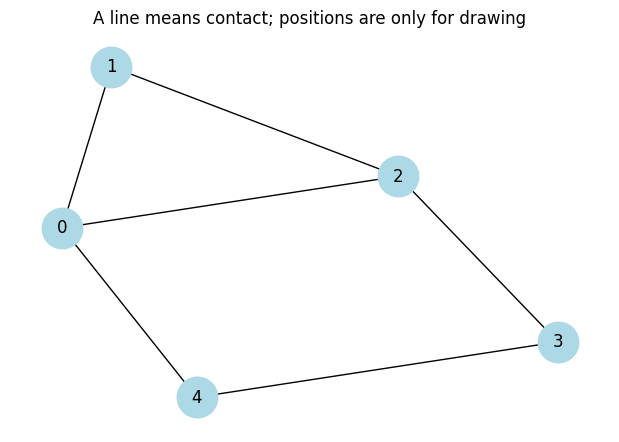

In [10]:
archi = [(0, 1), (0, 2), (1, 2), (2, 3), (3, 4), (4, 0)] # Ogni coppia rappresenta un arco

G = nx.Graph()                # network vuoto
G.add_edges_from(archi)       # network finale

plt.figure(figsize=(6, 4))
nx.draw(G, with_labels=True, node_color="lightblue", node_size=850)
plt.title("A line means contact; positions are only for drawing")
plt.show()

Text(0.5, 1.0, 'Undirected graph + isolated node')

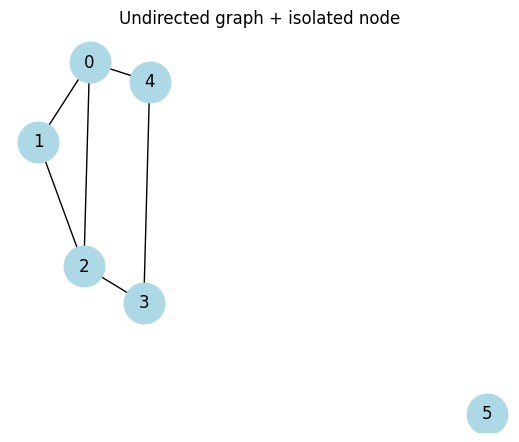

In [19]:
# 1) NETWORK NON DIRETTO CON NODO ISOLATO
G.add_node(5)                  # Aggiunge un nodo isolato (senza collegamenti)

plt.figure(figsize=(5, 4))
nx.draw(G, with_labels=True, node_color="lightblue", node_size=850)
plt.title("Undirected graph + isolated node")

`nx` is the short name we gave NetworkX, a library that stores and draws networks. `G` is our network object.

In [11]:
print("Nodes:", list(G.nodes()))
print("Edges:", list(G.edges()))
print("People:", G.number_of_nodes())
print("Contacts:", G.number_of_edges())

Nodes: [0, 1, 2, 3, 4]
Edges: [(0, 1), (0, 2), (0, 4), (1, 2), (2, 3), (3, 4)]
People: 5
Contacts: 6


A person's **neighbours** are their direct contacts. Their **degree** is the number of those contacts. The degree does not tell us how many neighbours are infected.

`G.neighbors(2)` gives an iterable: `list(...)` makes its contents easy to read.

In [12]:
print("Neighbours of 2:", list(G.neighbors(2)))
print("Degree of 2:", G.degree[2])

for person in G.nodes():
    print(person, "has", G.degree[person], "contacts")

Neighbours of 2: [0, 1, 3]
Degree of 2: 3
0 has 3 contacts
1 has 2 contacts
2 has 3 contacts
3 has 2 contacts
4 has 2 contacts


**Your turn:** print the neighbours and degree of person 3. Which person has degree zero?



In [ ]:
# TODO: neighbours and degree of person 3
# TODO: identify the person with no contacts

### 2 - Network variations: direct and weighted networks 


Text(0.5, 1.0, 'Directed graph')

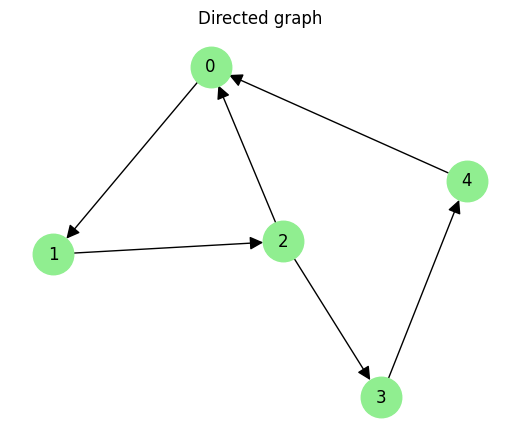

In [29]:
# 1) NETWORK DIRETTO
archi = [(0, 1), (2,0), (1, 2), (2, 3), (3, 4), (4, 0)] # Ogni coppia rappresenta un arco
G_directed = nx.DiGraph()      # DiGraph() crea un grafo diretto
G_directed.add_edges_from(archi)  # Gli archi hanno una direzione: 0 → 1, ecc.

plt.figure(figsize=(5, 4))
nx.draw(G_directed, with_labels=True, node_color="lightgreen",
        node_size=850, arrows=True, arrowsize=20)
plt.title("Directed graph")

/tmp/ipykernel_73390/1310016688.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


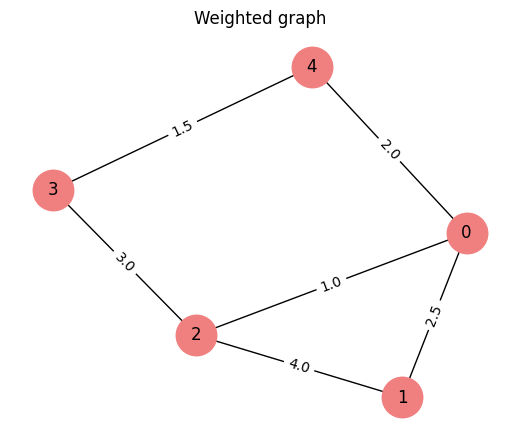

In [28]:

# 3) NETWORK PESATO
G_weighted = nx.Graph()        # Crea un grafo non diretto
archi_pesati = [
    (0, 1, 2.5),               # (nodo1, nodo2, peso)
    (0, 2, 1.0),
    (1, 2, 4.0),
    (2, 3, 3.0),
    (3, 4, 1.5),
    (4, 0, 2.0)
]
G_weighted.add_weighted_edges_from(archi_pesati)  # Aggiunge archi con pesi

plt.figure(figsize=(5, 4))
pos = nx.spring_layout(G_weighted, seed=42)       # Fissa le posizioni dei nodi
nx.draw(G_weighted, pos, with_labels=True, node_color="lightcoral", node_size=850)
nx.draw_networkx_edge_labels(
    G_weighted, pos,
    edge_labels=nx.get_edge_attributes(G_weighted, "weight")  # Mostra i pesi
)
plt.title("Weighted graph")

plt.tight_layout()
plt.show()

### 3 - A path is a sequence of contacts 

A **path** follows edges from one person to another. People on a path need not be direct neighbours. Infection needs time and successful transmissions to travel along it.

Predict the result before running:

In [ ]:
print("A shortest path from 0 to 4:", nx.shortest_path(G, 0, 4))
print("Is there any path from 0 to 3?", nx.has_path(G, 0, 3))

A shortest path from 0 to 4: [0, 4]
Is there any path from 0 to 5? True


**Your turn:** make a copy `H`, then remove contact `(2, 3)`. Can infection from 0 still reach 4? Draw the new network.

**Hint:** `H = G.copy()`, `H.remove_edge(2, 3)` and `nx.has_path(H, 0, 4)`. A **connected component** is a group within which every person can be reached through a path.

In [ ]:
# TODO: copy, remove one edge, check the path and draw

### 4 - Generate an Erdős–Rényi network

In an **Erdős–Rényi network**, each possible pair is connected independently with probability `p_edge`. This probability builds the graph; it is not a probability of catching the disease.

`seed` makes this random graph reproducible. Reusing it gives the same graph.

This is the pseudocode:

```
# INPUT: N (numero di nodi), p (probabilità di connessione)

1. Crea un network vuoto G
2. Aggiungi N nodi
3. Per ogni coppia di nodi (i, j), con i < j:
       - Genera un numero casuale r tra 0 e 1
       - Se r < p:
             aggiungi un arco tra i e j
4. Restituisci G
```

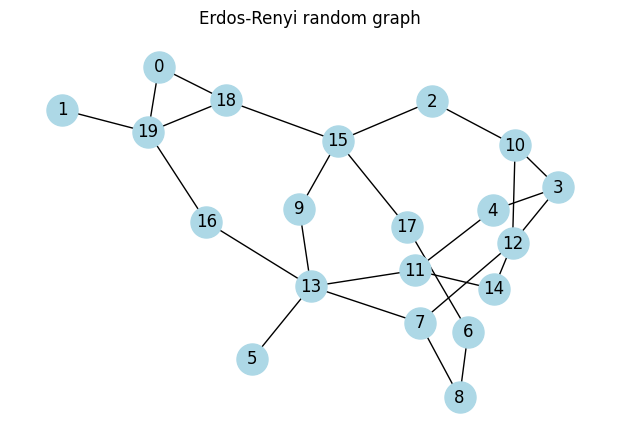

In [ ]:
import random

N = 20
p = 0.15
G = nx.Graph() 
G.add_nodes_from(range(N))          # aggiungiamo prima i nodi senza collegarli tra loro

### TODO: aggiungere gli archi con probabilità p seguendo lo pseudocodice

plt.figure(figsize=(6, 4))
nx.draw(G, with_labels=True, node_color="lightblue", node_size=500)
plt.title("Erdos-Renyi random graph")
plt.show()

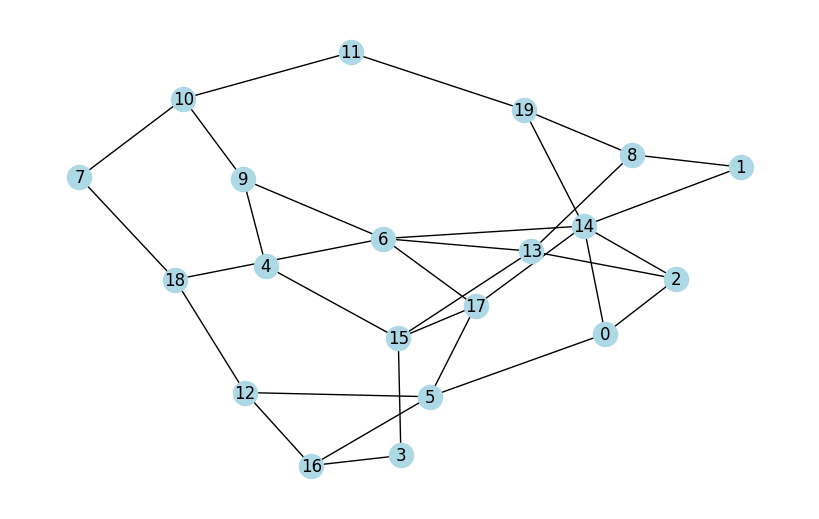

Number of contacts: 32


In [30]:
N = 20
p_edge = 0.15
random_graph = nx.erdos_renyi_graph(N, p_edge, seed=4)
positions = nx.spring_layout(random_graph, seed=4)
plt.figure(figsize=(8, 5))
nx.draw(random_graph, positions, with_labels=True, node_color="lightblue")
plt.show()
print("Number of contacts:", random_graph.number_of_edges())

### 5 - Generate a Barabasi albert Network

https://www.youtube.com/watch?v=jMRW-gG_VXU

Pseudocodice:

```
# INPUT: N (numero finale di nodi), m (archi per nuovo nodo)

1. Crea un network iniziale con m+1 nodi tutti collegati

2. Finché il numero di nodi è minore di N:
       - Aggiungi un nuovo nodo i 
       - Calcola il grado di ogni nodo esistente
       - Seleziona m nodi distinti con probabilità
         proporzionale al loro grado:
         
                P(j) = degree(j) / sum(degrees)
         *hint: https://www.w3schools.com/python/ref_random_choices.asp
         
       - Collega il nuovo nodo i ai m nodi selezionati

3. Restituisci G
```

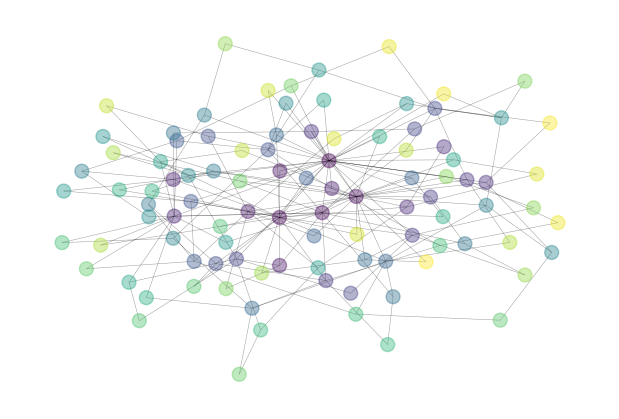

In [ ]:
#Create an Barabasi-Albert scale-free network
def ba(N, m):

    m0 = 4
    G = nx.complete_graph(m0)  # Initial clique with m0 nodes

    for index_node in range(m0, N):

        # 1. Get existing nodes
        G_nodes = ##todo

        # 2. Compute degrees
        k_list = ##todo

        # 3. Compute preferential attachment probabilities (see pseudocode)
        p = ##todo

        # 4. Sample m distinct existing nodes
        sampled_nodes = np.random.choice(
        ##todo
        )

        # 5. Add the new node and connect it to sampled nodes
        G.add_node(index_node)

        edges = [(index_node, node) for node in sampled_nodes]
        G.add_edges_from(edges)

    return G


N = 100
m = 2

G = ba(N, m)

plt.figure(figsize=(6, 4))
nx.draw(
    G,
    node_color=list(G.nodes),
    cmap=plt.cm.viridis,
    node_size=100,
    alpha=0.4,
    edge_color="black",
    width=0.35
)

plt.title("Barabási–Albert network")
plt.show()

In [ ]:
# con chatgpt: creiamo una gif che mostri la creazione del network 


### Confronto finale tra i due modelli

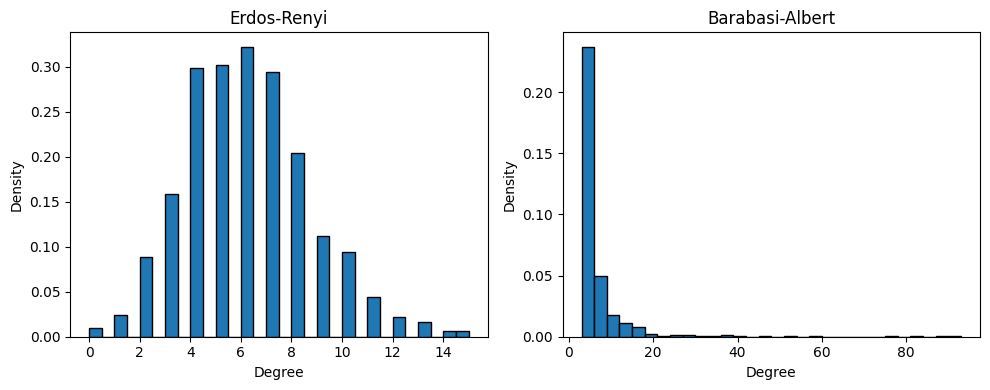

In [40]:
import networkx as nx
import matplotlib.pyplot as plt

N = 1000
m = 3

# Stesso numero di nodi e approssimativamente lo stesso grado medio
G_ER = nx.erdos_renyi_graph(N, p=2*m/(N-1), seed=42)
G_BA = nx.barabasi_albert_graph(N, m=m, seed=42)

plt.figure(figsize=(10, 4))

for i, (G, title) in enumerate([(G_ER, "Erdos-Renyi"),
                                 (G_BA, "Barabasi-Albert")]):

    degrees = [d for _, d in G.degree()]

    plt.subplot(1, 2, i+1)
    plt.hist(degrees, bins=30, density=True, edgecolor="black")
    plt.xlabel("Degree")
    plt.ylabel("Density")
    plt.title(title)

plt.tight_layout()
plt.show()

ER → binomiale (circa Poisson nel limite sparso). Ogni coppia di nodi ha la stessa probabilità \(p\) di essere collegata, indipendentemente dal grado. La distribuzione è binomiale (approssimativamente Poisson per network grandi e sparsi).

BA → power law con esponente asintotico circa 3. Nel modello Barabási–Albert, i nuovi nodi preferiscono collegarsi a quelli che hanno già molti collegamenti. Rich get richer!! Power law P(k) ~ k-3